# <center>Own EDA<center> 
<br>
<br>

### Background: <br>
The data source is https://www.netflix.com/tudum/top10 <br>
We downloaded 3 xlsx files named global_weekly, globall_alltime and country_weekly that we merged into netflix.csv and the EDA is based on it.

In [1]:
import duckdb
import pandas as pd

### Creating a dataframe and checking few rows

In [2]:
path = r"C:\Users\girau\Documents\G9\Netflix_Analytics_DE_UX\data\processed\netflix.csv"
df = pd.read_csv(path)
df.head(3)

,Unnamed: 0,country_name,country_iso2,week,country_category,country_weekly_rank,show_title,season_title,country_cumulative_weeks_in_top_10,global_category,global_weekly_rank,global_weekly_hours_viewed,runtime,global_weekly_views,global_cumulative_weeks_in_top_10
0,0,Argentina,AR,2026-03-15,Films,1,War Machine,NaN,2,Films (English),1.0,80600000.0,109.002,44400000.0,2.0
1,1,Argentina,AR,2026-03-15,Films,2,Strangers in the Park,NaN,2,Films (Non-English),10.0,1600000.0,115.998,800000.0,2.0
2,2,Argentina,AR,2026-03-15,Films,3,Joker: Folie à Deux,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458338 entries, 0 to 458337
Data columns (total 15 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Unnamed: 0                          458338 non-null  int64  
 1   country_name                        458338 non-null  object 
 2   country_iso2                        458338 non-null  object 
 3   week                                458338 non-null  object 
 4   country_category                    458338 non-null  object 
 5   country_weekly_rank                 458338 non-null  int64  
 6   show_title                          458338 non-null  object 
 7   season_title                        223904 non-null  object 
 8   country_cumulative_weeks_in_top_10  458338 non-null  int64  
 9   global_category                     306075 non-null  object 
 10  global_weekly_rank                  306075 non-null  float64
 11  global_weekly_hours_viewed

In [4]:
df.columns.tolist()

['Unnamed: 0',
 'country_name',
 'country_iso2',
 'week',
 'country_category',
 'country_weekly_rank',
 'show_title',
 'season_title',
 'country_cumulative_weeks_in_top_10',
 'global_category',
 'global_weekly_rank',
 'global_weekly_hours_viewed',
 'runtime',
 'global_weekly_views',
 'global_cumulative_weeks_in_top_10']

##### "week" is already datetime64, so no conversion needed during cleaning!



In [5]:
# --- Suppressing unwanted "Unnamed" column ---
df = df.drop(columns=["Unnamed: 0"], errors="ignore")  # drop it right away
df.head(1)

,country_name,country_iso2,week,country_category,country_weekly_rank,show_title,season_title,country_cumulative_weeks_in_top_10,global_category,global_weekly_rank,global_weekly_hours_viewed,runtime,global_weekly_views,global_cumulative_weeks_in_top_10
0,Argentina,AR,2026-03-15,Films,1,War Machine,NaN,2,Films (English),1.0,80600000.0,109.002,44400000.0,2.0


### Counting numbers of raws and columns


In [6]:
df.shape
print(f"File has respectively: raws, columns: {df.shape}")

File has respectively: raws, columns: (458338, 14)


### Checking the columns

In [7]:
# --- Viewing the columns ---
df.columns

Index(['country_name', 'country_iso2', 'week', 'country_category',
       'country_weekly_rank', 'show_title', 'season_title',
       'country_cumulative_weeks_in_top_10', 'global_category',
       'global_weekly_rank', 'global_weekly_hours_viewed', 'runtime',
       'global_weekly_views', 'global_cumulative_weeks_in_top_10'],
      dtype='object')

### Note: No beneficial to use .describe() as the most interesting columns are categorical "country_name", "show_title" and "week"

In [8]:
# --- Uncomment below if you need to see it ---
# df.describe()

### Distribution films Vs series

In [9]:
df["country_category"].value_counts()

country_category
Films    229208
TV       229130
Name: count, dtype: int64

### How many countries are in the dataset?

In [10]:
# --- Unique country count ---
df["country_name"].nunique()


94

In [11]:
# --- Country and their number of rows ---
df["country_name"].value_counts()

country_name
Argentina               4922
Bahamas                 4922
Chile                   4922
Colombia                4922
Brazil                  4922
                        ... 
Sweden                  4920
United States           4920
United Arab Emirates    4920
Vietnam                 4920
Russia                   700
Name: count, Length: 94, dtype: int64

### The Russian case, why 700 rows?

In [12]:
# --- Seeing the registered weeks ---
russia_weeks = df[df["country_name"] == "Russia"]["week"].value_counts()
print(f"The registered weeks (and years) for Russia are: {russia_weeks}")

The registered weeks (and years) for Russia are: week
2022-02-27    20
2022-02-20    20
2022-02-13    20
2022-02-06    20
2022-01-30    20
2022-01-23    20
2022-01-16    20
2022-01-09    20
2022-01-02    20
2021-12-26    20
2021-12-19    20
2021-12-12    20
2021-12-05    20
2021-11-28    20
2021-11-21    20
2021-11-14    20
2021-11-07    20
2021-10-31    20
2021-10-24    20
2021-10-17    20
2021-10-10    20
2021-10-03    20
2021-09-26    20
2021-09-19    20
2021-09-12    20
2021-09-05    20
2021-08-29    20
2021-08-22    20
2021-08-15    20
2021-08-08    20
2021-08-01    20
2021-07-25    20
2021-07-18    20
2021-07-11    20
2021-07-04    20
Name: count, dtype: int64


In [13]:
# --- Confirming the last week for Russia ---
df[df["country_name"] == "Russia"]["week"].max()

'2022-02-27'

### Dataset range (dates)

In [14]:
df['week'] = pd.to_datetime(df['week'])
year_counts = df['week'].dt.year.value_counts()
year_counts.sort_index(ascending=False)

week
2026    20460
2025    96720
2024    96798
2023    98580
2022    96900
2021    48880
Name: count, dtype: int64

In [15]:
# --- First date and the last of the dataset ---
df["week"].min(), df["week"].max()

(Timestamp('2021-07-04 00:00:00'), Timestamp('2026-03-15 00:00:00'))

### How many nulls?

In [16]:
df.isnull().sum()

country_name                               0
country_iso2                               0
week                                       0
country_category                           0
country_weekly_rank                        0
show_title                                 0
season_title                          234434
country_cumulative_weeks_in_top_10         0
global_category                       152263
global_weekly_rank                    152263
global_weekly_hours_viewed            152263
runtime                               277665
global_weekly_views                   277665
global_cumulative_weeks_in_top_10     152263
dtype: int64

The nulls counted above are not errors but structural.<br>
For example, the "season_title" column contains many NaN because movies have no season. Another example is for column "global_weekly_rank", if a film only charted locally in one country but not globally, there is no global rank to record it.<br>
The important nulls would be the ones in the columns: "country_name", "show_title" or "week".<br>
So I will just replace some of them with "Not applciable" as N/A in the cleaning section below.

### Focus on the Nordics (as the demos with UX will focus on it)

In [17]:
# --- Note: So far I have used "df" and I will keep it. It is the complete datfaframe* 
# --- Below I create another dataframe/a filter of "df" for the Nordics called df_nordics, to avoid to have to repaet every time** ---

df_nordics = df[df["country_name"].isin(['Iceland', 'Norway', 'Sweden', 'Finland', 'Denmark'])]
duckdb.register("df_nordics", df_nordics)

In [18]:
# --- Checking what Nordic countries we have ---
duckdb.sql("""
SELECT 
    country_name, COUNT(*) as rows
FROM 
    df_nordics
WHERE 
    country_name IN ('Iceland', 'Norway', 'Sweden', 'Finland', 'Denmark')
GROUP BY country_name
ORDER BY rows DESC
""").df()

,country_name,rows
0,Finland,4921
1,Iceland,4921
2,Sweden,4920
3,Norway,4920
4,Denmark,4920


In [19]:
#--- Comparing starting and ending dates for the Nordic countries ---
duckdb.sql("""
SELECT 
    country_name, 
    MIN(week) AS start, 
    MAX(week) AS end, 
    COUNT(DISTINCT week) AS weeks
FROM 
    df_nordics
WHERE 
    country_name IN ('Iceland', 'Norway', 'Sweden', 'Finland', 'Denmark')
GROUP BY country_name
ORDER BY country_name
""").df()

,country_name,start,end,weeks
0,Denmark,2021-07-04,2026-03-15,246
1,Finland,2021-07-04,2026-03-15,246
2,Iceland,2021-07-04,2026-03-15,246
3,Norway,2021-07-04,2026-03-15,246
4,Sweden,2021-07-04,2026-03-15,246


In [20]:
# --- Films/series that spent the most time in the top 10 in Sweden in 2025 ---
duckdb.sql("""
SELECT 
    show_title, 
    COUNT(*) AS weeks_in_top10_2025
FROM 
    df_nordics
WHERE 
    country_name = 'Sweden'
AND YEAR(week) = 2025
GROUP BY show_title
ORDER BY weeks_in_top10_2025 DESC
LIMIT 10
""").df()

,show_title,weeks_in_top10_2025
0,KPop Demon Hunters,26
1,Squid Game,16
2,Dept. Q,13
3,Wednesday,12
4,Barracuda Queens,12
5,Sirens,11
6,Adolescence,11
7,Stranger Things,11
8,Love Is Blind,10
9,Love is Blind: Sweden,9


In [21]:
# --- Films and series distribution per nordic country ---
duckdb.sql("""
SELECT country_name, country_category, COUNT(*) as count
FROM df_nordics
WHERE country_name IN ('Iceland', 'Norway', 'Sweden', 'Finland', 'Denmark')
GROUP BY country_name, country_category
ORDER BY country_name
""").df()

,country_name,country_category,count
0,Denmark,Films,2460
1,Denmark,TV,2460
2,Finland,Films,2461
3,Finland,TV,2460
4,Iceland,Films,2461
5,Iceland,TV,2460
6,Norway,Films,2460
7,Norway,TV,2460
8,Sweden,Films,2460
9,Sweden,TV,2460


## <center>Data cleaning<center>

In [22]:
df.head(1)

,country_name,country_iso2,week,country_category,country_weekly_rank,show_title,season_title,country_cumulative_weeks_in_top_10,global_category,global_weekly_rank,global_weekly_hours_viewed,runtime,global_weekly_views,global_cumulative_weeks_in_top_10
0,Argentina,AR,2026-03-15,Films,1,War Machine,NaN,2,Films (English),1.0,80600000.0,109.002,44400000.0,2.0


### Any duplicates?

In [23]:
# Counting the duplicates
df.duplicated().sum()

np.int64(0)

### The NaN question

In [24]:
# --- Distinction between the columns with numbers and the ones having text
# --- I keep NaN in the numeric columns to avoid possible issues with calculations ---
# --- In the text columns, I replace NaN ---> N/A for "Not applicable" 

text_columns = ["season_title", "global_category"]
df[text_columns] = df[text_columns].fillna("N/A")
df.head(3)

,country_name,country_iso2,week,country_category,country_weekly_rank,show_title,season_title,country_cumulative_weeks_in_top_10,global_category,global_weekly_rank,global_weekly_hours_viewed,runtime,global_weekly_views,global_cumulative_weeks_in_top_10
0,Argentina,AR,2026-03-15,Films,1,War Machine,N/A,2,Films (English),1.0,80600000.0,109.002,44400000.0,2.0
1,Argentina,AR,2026-03-15,Films,2,Strangers in the Park,N/A,2,Films (Non-English),10.0,1600000.0,115.998,800000.0,2.0
2,Argentina,AR,2026-03-15,Films,3,Joker: Folie à Deux,N/A,1,N/A,NaN,NaN,NaN,NaN,NaN


### Renaming columns: country_iso2 and country_category

In [25]:
# --- Renaming ---
df = duckdb.sql("""---sql
SELECT * RENAME (
    country_iso2 AS country_code, 
    country_category AS film_or_tv_series,
    runtime AS duration_minutes)
FROM 
    df
""").df()
df.head(1)

,country_name,country_code,week,film_or_tv_series,country_weekly_rank,show_title,season_title,country_cumulative_weeks_in_top_10,global_category,global_weekly_rank,global_weekly_hours_viewed,duration_minutes,global_weekly_views,global_cumulative_weeks_in_top_10
0,Argentina,AR,2026-03-15,Films,1,War Machine,N/A,2,Films (English),1.0,80600000.0,109.002,44400000.0,2.0


### !!! Please note: Needed to add again df_nordics below after the renaming of columns (just above)


In [26]:
df_nordics = df[df["country_name"].isin(['Iceland', 'Norway', 'Sweden', 'Finland', 'Denmark'])]
duckdb.register("df_nordics", df_nordics)

### Rounding the runtime column

In [27]:
# NaN --> 0 | rounding | float --> integer
df['duration_minutes'] = df['duration_minutes'].fillna(0).round(0).astype(int)
df.head(2)

,country_name,country_code,week,film_or_tv_series,country_weekly_rank,show_title,season_title,country_cumulative_weeks_in_top_10,global_category,global_weekly_rank,global_weekly_hours_viewed,duration_minutes,global_weekly_views,global_cumulative_weeks_in_top_10
0,Argentina,AR,2026-03-15,Films,1,War Machine,N/A,2,Films (English),1.0,80600000.0,109,44400000.0,2.0
1,Argentina,AR,2026-03-15,Films,2,Strangers in the Park,N/A,2,Films (Non-English),10.0,1600000.0,116,800000.0,2.0


### The use of .str.lower() to distinguish

In [28]:
# As some of the data will be displayed in visuals I would keep the "country_name", "country_codes", "show_title" and "season_title" with a capital letter.
# --- 2 columns can be in small letters ---

df["film_or_tv_series"] = df["film_or_tv_series"].str.lower()
df["global_category"] = df["global_category"].str.lower()
df.head(1)


,country_name,country_code,week,film_or_tv_series,country_weekly_rank,show_title,season_title,country_cumulative_weeks_in_top_10,global_category,global_weekly_rank,global_weekly_hours_viewed,duration_minutes,global_weekly_views,global_cumulative_weeks_in_top_10
0,Argentina,AR,2026-03-15,films,1,War Machine,N/A,2,films (english),1.0,80600000.0,109,44400000.0,2.0


## <center>Exporting the cleaned dataset<center>

In [29]:
df.to_csv(r"C:\Users\girau\Documents\G9\Netflix_Analytics_DE_UX\data\processed\netflix_cleaned.csv", index=False)

## <center>Visualization<center>

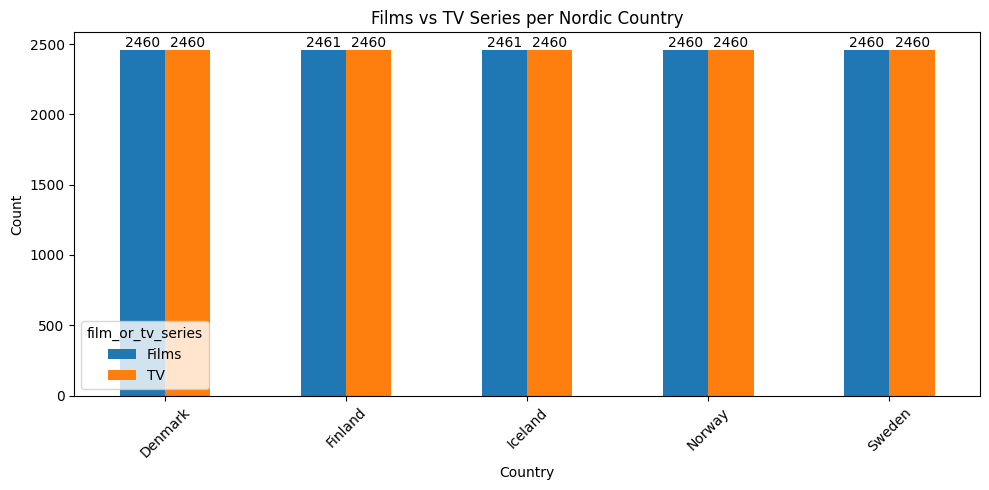

In [30]:
import matplotlib.pyplot as plt

# --- Limiting to the Nordics ---
nordic_categories = duckdb.sql("""
SELECT
    country_name,
    film_or_tv_series,
    COUNT(*) as count
FROM 
    df_nordics
WHERE 
    country_name IN ('Iceland', 'Norway', 'Sweden', 'Finland', 'Denmark')
GROUP BY 
    country_name, 
    film_or_tv_series
ORDER BY country_name""").df()


nordic_categories_pivot = nordic_categories.pivot(index="country_name", columns="film_or_tv_series", values="count")
ax = nordic_categories_pivot.plot(kind="bar", figsize=(10, 5))
for container in ax.containers:
    ax.bar_label(container)
plt.title("Films vs TV Series per Nordic Country")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

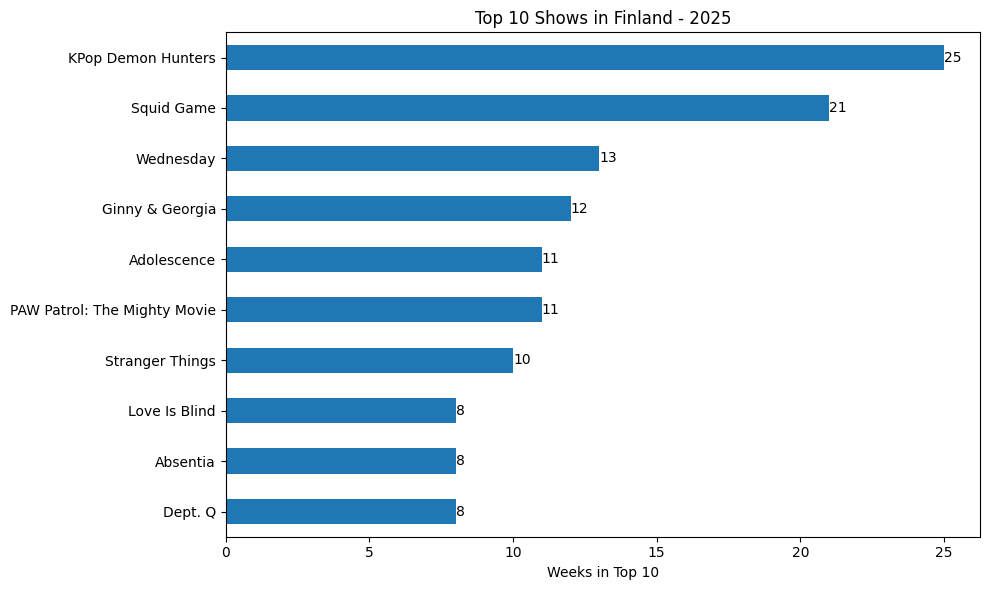

In [31]:
# --- Top films or series in Finland in 2025 ---
finland_2025 = duckdb.sql("""
    SELECT 
        show_title, 
        COUNT(*) AS weeks_in_top10_2025
    FROM 
        df_nordics
    WHERE 
        country_name = 'Finland' AND YEAR(week) = 2025
    GROUP BY 
        show_title
    ORDER BY 
        weeks_in_top10_2025 DESC
    LIMIT 10
""").df()

ax = finland_2025.plot(kind="barh", x="show_title", y="weeks_in_top10_2025", figsize=(10, 6), legend=False)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Top 10 Shows in Finland - 2025")
plt.xlabel("Weeks in Top 10")
plt.ylabel("")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

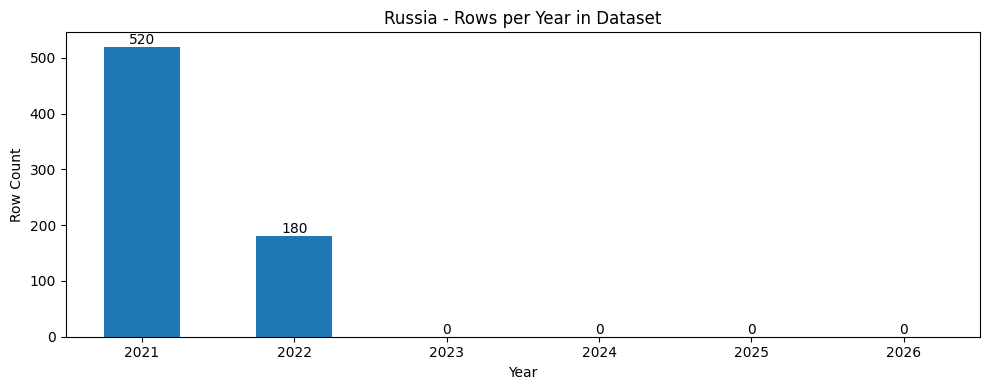

In [32]:
# --- Visual confirming the drop in Russia's number of rows ---
russia_counts = df[df["country_name"] == "Russia"]["week"].dt.year.value_counts()
russia_counts = russia_counts.sort_index()
russia_counts = russia_counts.reindex([2021, 2022, 2023, 2024, 2025, 2026])

ax = russia_counts.plot(kind="bar", figsize=(10, 4))
for container in ax.containers:
    ax.bar_label(container)
plt.title("Russia - Rows per Year in Dataset")
plt.xlabel("Year")
plt.ylabel("Row Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## <center>Storytelling<center>

In [33]:
import matplotlib.pyplot as plt
from pathlib import Path


In [34]:

# --- Create figures folder if it doesn't exist ---
Path("figures").mkdir(exist_ok=True)

In [35]:
# --- Colour palette (would have created a constants.py if I could have pushed it to the project repo) ---
GRAY_1 = "#BEBEBE"
GRAY_3 = "#646464"
GRAY_strong = "#323232"
RED_1  = "#E24B4A"

In [36]:
# --- We filter "Russia" in column country_name, extract the years and (unique) count the rows
russia_rows = df[df["country_name"] == "Russia"]["week"].dt.year.value_counts()
russia_rows = russia_rows.reindex([2021, 2022, 2023, 2024, 2025, 2026], fill_value=0)
russia_rows

week
2021    520
2022    180
2023      0
2024      0
2025      0
2026      0
Name: count, dtype: int64

In [37]:
# --- We need to sort the date (years, months) before ploting | I understood it after seeing the plot ---
russia_df = df[df["country_name"] == "Russia"].copy()
russia_df["year_month"] = russia_df["week"].dt.to_period("M")           # from timestamps to period, here "M" for month
russia_months = russia_df["year_month"].value_counts().sort_index()    # counting and sorting the calender order
#russia_months.index = russia_months.index.strftime("%b %Y")
 

# Line chart: Showing work progress

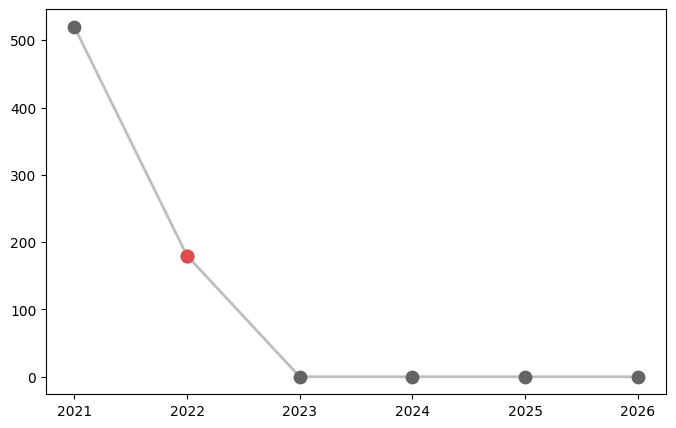

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(len(russia_rows)), russia_rows.values, color=GRAY_1, linewidth=2)
#ax.scatter([1], [russia_rows.iloc[1]], color=RED_1, s=80, zorder=3)
ax.scatter(range(len(russia_rows)), russia_rows.values, color=GRAY_3, s=80, zorder=3)
ax.scatter([1], [russia_rows.iloc[1]], color=RED_1, s=80, zorder=4)
ax.set_xticks(range(len(russia_rows)))
ax.set_xticklabels(russia_rows.index, rotation=0);

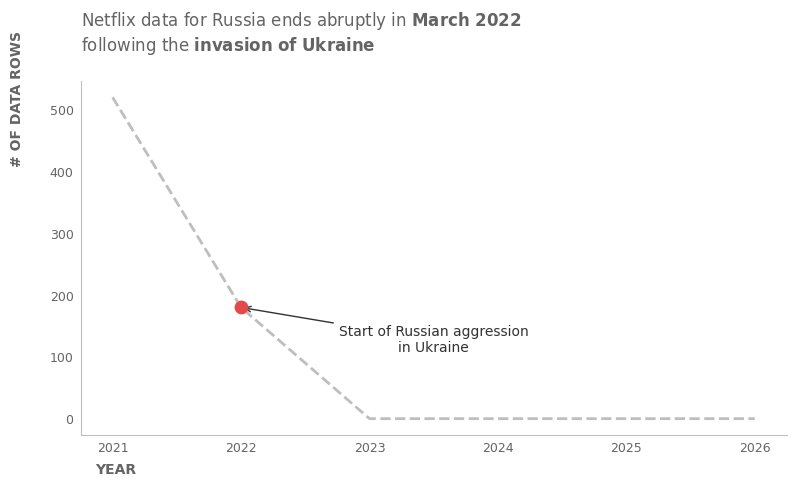

In [39]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(range(len(russia_rows)), russia_rows.values, color=GRAY_1, linewidth=2, zorder=2, linestyle="--")

ax.scatter([1], [russia_rows.iloc[1]], color=RED_1, s=80, zorder=4)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(GRAY_1)
ax.tick_params(axis="both", labelsize=9, colors=GRAY_3, length=0, pad=5)
ax.set_xticks(range(len(russia_rows)))
ax.set_xticklabels(russia_rows.index, rotation=0);

ax.set_ylabel("# OF DATA ROWS", color=GRAY_3, fontweight="bold", rotation=90, labelpad=10)
ax.set_xlabel("YEAR", color=GRAY_3, fontweight="bold")
ax.xaxis.set_label_coords(0.05, -0.08)
ax.yaxis.set_label_coords(-0.08, 0.95)

ax.set_title(
    "Netflix data for Russia ends abruptly in "
    + r"$\bf{March\ 2022}$"
    + "\nfollowing the "
    + r"$\bf{invasion\ of\ Ukraine}$",
    pad=22, color=GRAY_3, loc="left",
)

ax.annotate(
    text="Start of Russian aggression\nin Ukraine",
    xy=(1, russia_rows.iloc[1]),
    xytext=(2.5, russia_rows.iloc[1] * 0.6),
    arrowprops=dict(arrowstyle="->", color=GRAY_strong),
    fontsize=10,
    color=GRAY_strong,
    ha="center",
)


fig.tight_layout()
fig.savefig("figures/russia_storytelling.png", bbox_inches="tight")
plt.show()

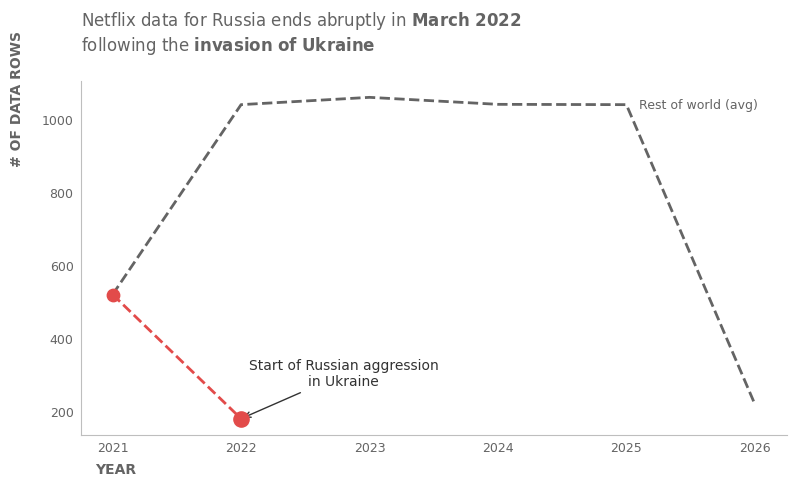

In [40]:
# Graph 1 with falling line -- not so good to show

russia_2022 = russia_rows[russia_rows > 0]
world_df = df[df["country_name"] != "Russia"]
world_yearly = world_df.groupby(world_df["week"].dt.year)["country_name"].count() / world_df["country_name"].nunique()
world_yearly = world_yearly.reindex([2021, 2022, 2023, 2024, 2025, 2026], fill_value=0)
world_continue = world_yearly[world_yearly > 0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(len(russia_2022)), russia_2022.values, color=RED_1, linewidth=2, linestyle="--", zorder=2)
ax.plot(range(len(world_continue)), world_continue.values, color=GRAY_3, linewidth=2, linestyle="--", zorder=2)
#ax.plot(range(len(russia_rows)), russia_rows.values, color=GRAY_1, linewidth=2, zorder=2, linestyle="--")


ax.scatter(range(len(russia_2022)), russia_2022.values, color=RED_1, s=80, zorder=3)
ax.scatter([1], [russia_2022.iloc[1]], color=RED_1, s=120, zorder=4)
#ax.scatter([1], [russia_rows.iloc[1]], color=RED_1, s=80, zorder=4)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(GRAY_1)
ax.tick_params(axis="both", labelsize=9, colors=GRAY_3, length=0, pad=5)
ax.set_xticks(range(len(russia_rows)))
ax.set_xticklabels(russia_rows.index, rotation=0);

ax.set_ylabel("# OF DATA ROWS", color=GRAY_3, fontweight="bold", rotation=90, labelpad=10)
ax.set_xlabel("YEAR", color=GRAY_3, fontweight="bold")
ax.xaxis.set_label_coords(0.05, -0.08)
ax.yaxis.set_label_coords(-0.08, 0.95)

ax.set_title(
    "Netflix data for Russia ends abruptly in "
    + r"$\bf{March\ 2022}$"
    + "\nfollowing the "
    + r"$\bf{invasion\ of\ Ukraine}$",
    pad=22, color=GRAY_3, loc="left",
)



ax.annotate(
    text="Start of Russian aggression\nin Ukraine",
    xy=(1, russia_2022.iloc[1]),
    xytext=(1.8, russia_2022.iloc[1] * 1.5),
    arrowprops=dict(arrowstyle="->", color=GRAY_strong),
    fontsize=10,
    color=GRAY_strong,
    ha="center",
)


ax.text(4.1, world_continue.iloc[4], "Rest of world (avg)", color=GRAY_3, fontsize=9, va="center")


fig.tight_layout()
fig.savefig("figures/russia_storytelling.png", bbox_inches="tight")
plt.show()

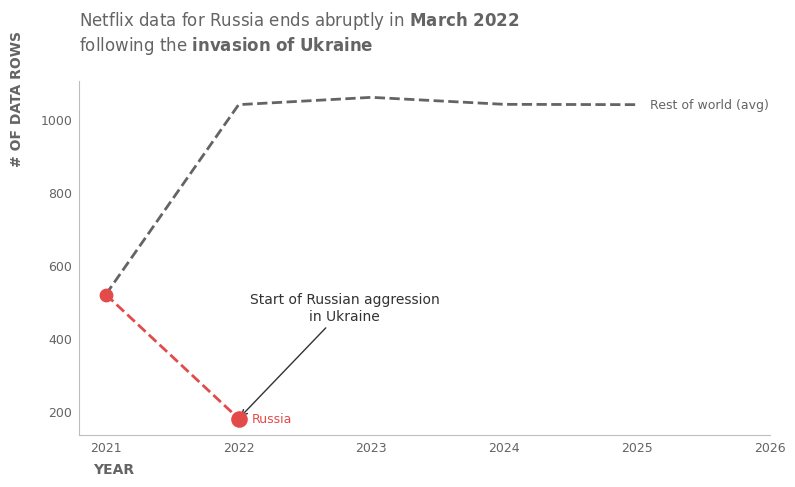

In [41]:
# Graph 2 no falling line but not so accurate (removed 2026) -- best version

russia_2022 = russia_rows[russia_rows > 0]
world_df = df[df["country_name"] != "Russia"]
world_yearly = world_df.groupby(world_df["week"].dt.year)["country_name"].count() / world_df["country_name"].nunique()
world_yearly = world_yearly.reindex([2021, 2022, 2023, 2024, 2025], fill_value=0)
world_continue = world_yearly[world_yearly > 0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(len(russia_2022)), russia_2022.values, color=RED_1, linewidth=2, linestyle="--", zorder=2)
ax.plot(range(len(world_continue)), world_continue.values, color=GRAY_3, linewidth=2, linestyle="--", zorder=2)
#ax.plot(range(len(russia_rows)), russia_rows.values, color=GRAY_1, linewidth=2, zorder=2, linestyle="--")


ax.scatter(range(len(russia_2022)), russia_2022.values, color=RED_1, s=80, zorder=3)
ax.scatter([1], [russia_2022.iloc[1]], color=RED_1, s=120, zorder=4)
#ax.scatter([1], [russia_rows.iloc[1]], color=RED_1, s=80, zorder=4)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(GRAY_1)
ax.tick_params(axis="both", labelsize=9, colors=GRAY_3, length=0, pad=5)
ax.set_xticks(range(len(russia_rows)))
ax.set_xticklabels(russia_rows.index, rotation=0);

ax.set_ylabel("# OF DATA ROWS", color=GRAY_3, fontweight="bold", rotation=90, labelpad=10)
ax.set_xlabel("YEAR", color=GRAY_3, fontweight="bold")
ax.xaxis.set_label_coords(0.05, -0.08)
ax.yaxis.set_label_coords(-0.08, 0.95)

ax.set_title(
    "Netflix data for Russia ends abruptly in "
    + r"$\bf{March\ 2022}$"
    + "\nfollowing the "
    + r"$\bf{invasion\ of\ Ukraine}$",
    pad=22, color=GRAY_3, loc="left",
)

ax.annotate(
    text="Start of Russian aggression\nin Ukraine",
    xy=(1, russia_2022.iloc[1]),
    xytext=(1.8, russia_2022.iloc[1] * 2.5),
    arrowprops=dict(arrowstyle="->", color=GRAY_strong),
    fontsize=10,
    color=GRAY_strong,
    ha="center",
)

ax.text(4.1, world_continue.iloc[4], "Rest of world (avg)", color=GRAY_3, fontsize=9, va="center")
ax.text(1.1, russia_rows.iloc[1], "Russia", color=RED_1, fontsize=9, va="center")


fig.tight_layout()
fig.savefig("figures/russia_storytelling.png", bbox_inches="tight")
plt.show()

In [42]:
print(world_yearly.mean())


940.167741935484
